# Sección: 01_eda_and_preprocessing.ipynb

### Importación de Librerías y Configuración
Este bloque prepara el entorno de trabajo y define las rutas de datos.
Usa `Path` para construir rutas de archivo reproducibles y asegura que `data/processed` exista.


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import joblib

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Rutas del proyecto
BASE_DIR = Path("..")
RAW_DATA_PATH = BASE_DIR / "data" / "raw"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Crear directorio procesado si no existe
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
print("✅ Librerías cargadas y rutas configuradas correctamente.")

✅ Librerías cargadas y rutas configuradas correctamente.


### Carga de Datos Crudos
Este paso importa el dataset original para análisis exploratorio y particionado.
El dataset contiene `Time`, `Amount`, `Class` y las 28 características PCA `V1`..`V28`.


In [ ]:
# Cargar dataset de tarjetas de crédito
df_full = pd.read_csv(RAW_DATA_PATH / "creditcard.csv")

print(f"Dataset de tarjetas de crédito (filas, columnas): {df_full.shape}")
df_full.head()

Dataset de tarjetas de crédito (filas, columnas): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Exploración Inicial (EDA)
Revisamos nulos y distribución de clases para validar la calidad del dataset.
Esto confirma el carácter altamente desbalanceado del problema de fraude.


In [ ]:
# Verificar valores nulos
print("🔍 Cantidad de valores nulos en el dataset:", df_full.isnull().sum().sum())

# Mapeo de clases para legibilidad (0: Normal/Lícita, 1: Fraudulenta/Ilícita)
class_map = {0: 'Lícita (0)', 1: 'Ilícita (1)'}
df_full['class_label'] = df_full['Class'].map(class_map)

# Distribución general de clases
print("\n📊 Distribución de Clases:")
print(df_full['class_label'].value_counts(dropna=False))

print("\n📈 Porcentaje de Distribución:")
print(df_full['class_label'].value_counts(normalize=True) * 100)

🔍 Cantidad de valores nulos en el dataset: 0

📊 Distribución de Clases:
class_label
Lícita (0)     284315
Ilícita (1)       492
Name: count, dtype: int64

📈 Porcentaje de Distribución:
class_label
Lícita (0)     99.827251
Ilícita (1)     0.172749
Name: proportion, dtype: float64


### Visualización de la Distribución de Clases

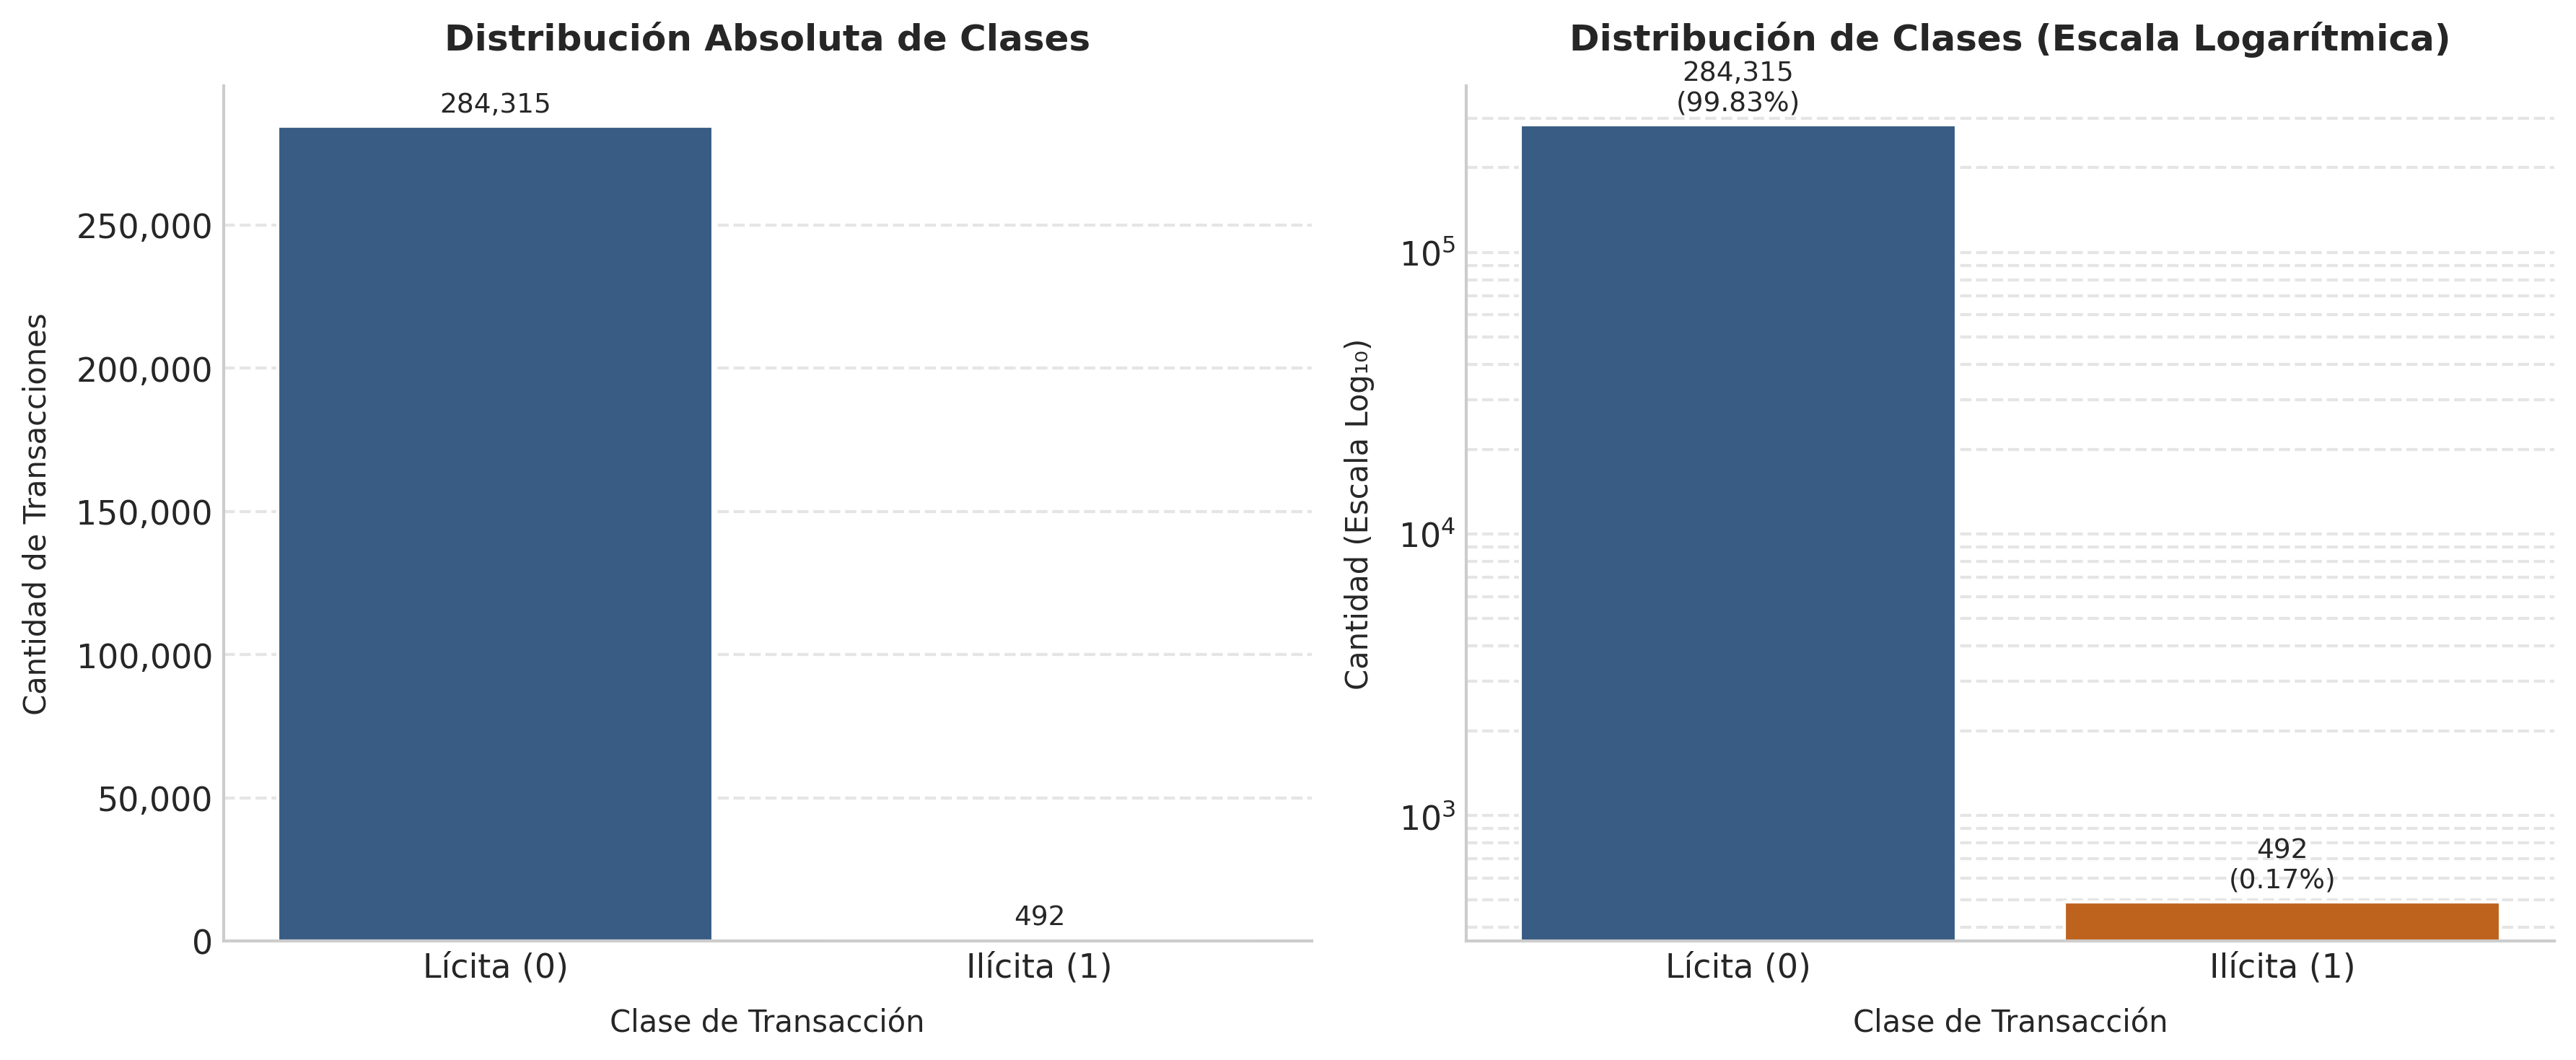

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo global para rigor científico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Paleta semántica con las claves exactas que tiene tu dataframe
palette = {'Lícita (0)': '#2b5c8f', 'Ilícita (1)': '#d95f02'}

# --- Gráfico 1: Escala Lineal ---
ax1 = axes[0]
sns.countplot(data=df_full, x='class_label', hue='class_label', palette=palette, ax=ax1, legend=False)
ax1.set_title("Distribución Absoluta de Clases", fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Clase de Transacción", fontsize=10, labelpad=8)
ax1.set_ylabel("Cantidad de Transacciones", fontsize=10, labelpad=8)
ax1.yaxis.set_major_formatter('{x:,.0f}')  # Separador de miles
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# Añadir valores exactos sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

# --- Gráfico 2: Escala Logarítmica ---
ax2 = axes[1]
sns.countplot(data=df_full, x='class_label', hue='class_label', palette=palette, ax=ax2, legend=False)
ax2.set_yscale('log')
ax2.set_title("Distribución de Clases (Escala Logarítmica)", fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Clase de Transacción", fontsize=10, labelpad=8)
ax2.set_ylabel("Cantidad (Escala Log₁₀)", fontsize=10, labelpad=8)
ax2.grid(axis='y', which='both', linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# Añadir valores/porcentajes sobre las barras en escala logarítmica
total = len(df_full)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total) * 100
        ax2.annotate(f'{int(height):,}\n({pct:.2f}%)',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

# Eliminar marcos superior y derecho
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Preprocesamiento y Escalado de Características (`Time` y `Amount`)
Tras verificar el dataset, escalamos sólo `Time` y `Amount` para evitar data leakage.
Las características `V1`..`V28` ya están normalizadas por PCA, por lo que no se reescalan.


In [ ]:
# 1. Copia de trabajo y reordenamiento inicial
# Se usa una copia para no alterar el dataframe original cargado.
df_processed = df_full.copy()
df_processed.drop(columns=['class_label'], inplace=True, errors='ignore')

# Reordenar para dejar la variable objetivo 'Class' al final
cols = [col for col in df_processed.columns if col != 'Class'] + ['Class']
df_processed = df_processed[cols]

# 2. División preliminar por clases
# El autoencoder se entrena solo con transacciones normales (Clase 0).
df_normal = df_processed[df_processed['Class'] == 0].copy()
df_fraud = df_processed[df_processed['Class'] == 1].copy()

# Split de la clase normal (60% Train, 20% Val, 20% Test)
normal_train, normal_holdout = train_test_split(
    df_normal,
    test_size=0.4,
    random_state=42,
    shuffle=True
)
normal_val, normal_test = train_test_split(
    normal_holdout,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Split de la clase fraudulenta (50% Val, 50% Test)
# Las transacciones fraudulentas no se usan para entrenar el autoencoder.
fraud_val, fraud_test = train_test_split(
    df_fraud,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Unir y mezclar los conjuntos de Validación y Test
df_val = pd.concat([normal_val, fraud_val]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([normal_test, fraud_test]).sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Ajuste de Escaladores SIN Data Leakage
# Ajustamos los escaladores solo con el conjunto de entrenamiento normal.
scaler_amount = RobustScaler()
scaler_time = RobustScaler()

# Copia explícita para evitar SettingWithCopyWarning
df_train = normal_train.copy().reset_index(drop=True)

# Fit solo en entrenamiento normal
df_train['scaled_amount'] = scaler_amount.fit_transform(df_train[['Amount']])
df_train['scaled_time'] = scaler_time.fit_transform(df_train[['Time']])

# Transform en validación y test usando los parámetros aprendidos
df_val['scaled_amount'] = scaler_amount.transform(df_val[['Amount']])
df_val['scaled_time'] = scaler_time.transform(df_val[['Time']])

df_test['scaled_amount'] = scaler_amount.transform(df_test[['Amount']])
df_test['scaled_time'] = scaler_time.transform(df_test[['Time']])

# Eliminar columnas originales sin escalar
for df in [df_train, df_val, df_test]:
    df.drop(columns=['Time', 'Amount'], inplace=True)

# Definir columnas de características
feature_columns = [col for col in df_train.columns if col != 'Class']

# Extraer matrices NumPy
X_train_licit = df_train[feature_columns].values
X_val = df_val[feature_columns].values
X_test = df_test[feature_columns].values

y_val = df_val['Class'].values
y_test = df_test['Class'].values

print("✅ División de datos y escalado completados correctamente:")
print(f"   - X_train_licit: {X_train_licit.shape}")
print(f"   - X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"   - X_test: {X_test.shape}, y_test: {y_test.shape}")

✅ División de datos y escalado completados correctamente:
   - X_train_licit: (170589, 30)
   - X_val: (57109, 30), y_val: (57109,)
   - X_test: (57109, 30), y_test: (57109,)


### Guardado de Datos Procesados y Artefactos
Preservamos artefactos reproducibles para entrenamiento, validación y test.
Los escaladores guardados permiten aplicar la misma transformación en inferencia futura.


In [ ]:

# 4. Guardar artefactos corregidos
np.save(PROCESSED_DATA_PATH / "X_train_licit.npy", X_train_licit)
np.save(PROCESSED_DATA_PATH / "X_val.npy", X_val)
np.save(PROCESSED_DATA_PATH / "X_test.npy", X_test)
np.save(PROCESSED_DATA_PATH / "y_val.npy", y_val)
np.save(PROCESSED_DATA_PATH / "y_test.npy", y_test)

joblib.dump(scaler_amount, PROCESSED_DATA_PATH / "scaler_amount.pkl")
joblib.dump(scaler_time, PROCESSED_DATA_PATH / "scaler_time.pkl")

print(f"📦 Arrays y escaladores guardados correctamente en: {PROCESSED_DATA_PATH}")

📦 Arrays y escaladores guardados correctamente en: ..\data\processed


# Sección: 02_autoencoder_training.ipynb

### Importación de Librerías y Configuración de Dispositivo
Este bloque prepara el entorno de entrenamiento y asegura reproducibilidad.
Incluye detección de hardware y ajuste de semillas para resultados consistentes.


In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Permitir importar módulos desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Fijar semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# CuDNN: reproducibilidad
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Detección de hardware (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Entrenando en dispositivo: {device}")

⚡ Entrenando en dispositivo: cpu


### Carga de Datos Procesados y PyTorch DataLoader
Se carga el conjunto de entrenamiento de transacciones normales.
El DataLoader usa `drop_last=True` para evitar batchs incompletos con BatchNorm1d.


In [ ]:
# Ruta de los datos procesados para Credit Card
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "creditcard"
if not (PROCESSED_DATA_PATH / "X_train_licit.npy").exists():
    PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Cargar dataset de entrenamiento LÍCITO (Credit Card)
X_train_licit = np.load(PROCESSED_DATA_PATH / "X_train_licit.npy")
print(f"Dimensiones de X_train_licit (Credit Card): {X_train_licit.shape}")

# Convertir a Tensors de PyTorch
X_train_tensor = torch.tensor(X_train_licit, dtype=torch.float32)

# Crear Dataset y DataLoader con drop_last=True para prevenir fallos en BatchNorm1d
BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

Dimensiones de X_train_licit (Credit Card): (170589, 30)


### Instanciación del Modelo, Criterio y Optimizador
Se define la arquitectura del autoencoder y se configuran sus hiperparámetros.
La pérdida utilizada es `MSELoss`, adecuada para reconstrucción de entradas continuas.


In [ ]:
# Parámetros para Credit Card
INPUT_DIM = X_train_licit.shape[1]  # Detección automática del número de columnas
BOTTLENECK_DIM = 14                 # Compresión en espacio latente
LEARNING_RATE = 1e-3
EPOCHS = 50

# Instanciar modelo
model = Autoencoder(input_dim=INPUT_DIM, bottleneck_dim=BOTTLENECK_DIM).to(device)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=14, bias=True)
    (9): LeakyReLU(negative_slope=0.2)
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=Tru

### Bucle de Entrenamiento (Training Loop)
Este bloque realiza la optimización del autoencoder sobre el conjunto normal.
Se registra la pérdida por época para monitorizar convergencia.


In [ ]:
train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for batch in train_loader:
        inputs = batch[0].to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}] - Loss (MSE): {epoch_loss:.6f}")

Epoch [01/50] - Loss (MSE): 0.587219
Epoch [05/50] - Loss (MSE): 0.313577
Epoch [10/50] - Loss (MSE): 0.281149
Epoch [15/50] - Loss (MSE): 0.270742
Epoch [20/50] - Loss (MSE): 0.260408
Epoch [25/50] - Loss (MSE): 0.257460
Epoch [30/50] - Loss (MSE): 0.257312
Epoch [35/50] - Loss (MSE): 0.252940
Epoch [40/50] - Loss (MSE): 0.253846
Epoch [45/50] - Loss (MSE): 0.247520
Epoch [50/50] - Loss (MSE): 0.246998


### Visualización de la Curva de Pérdida

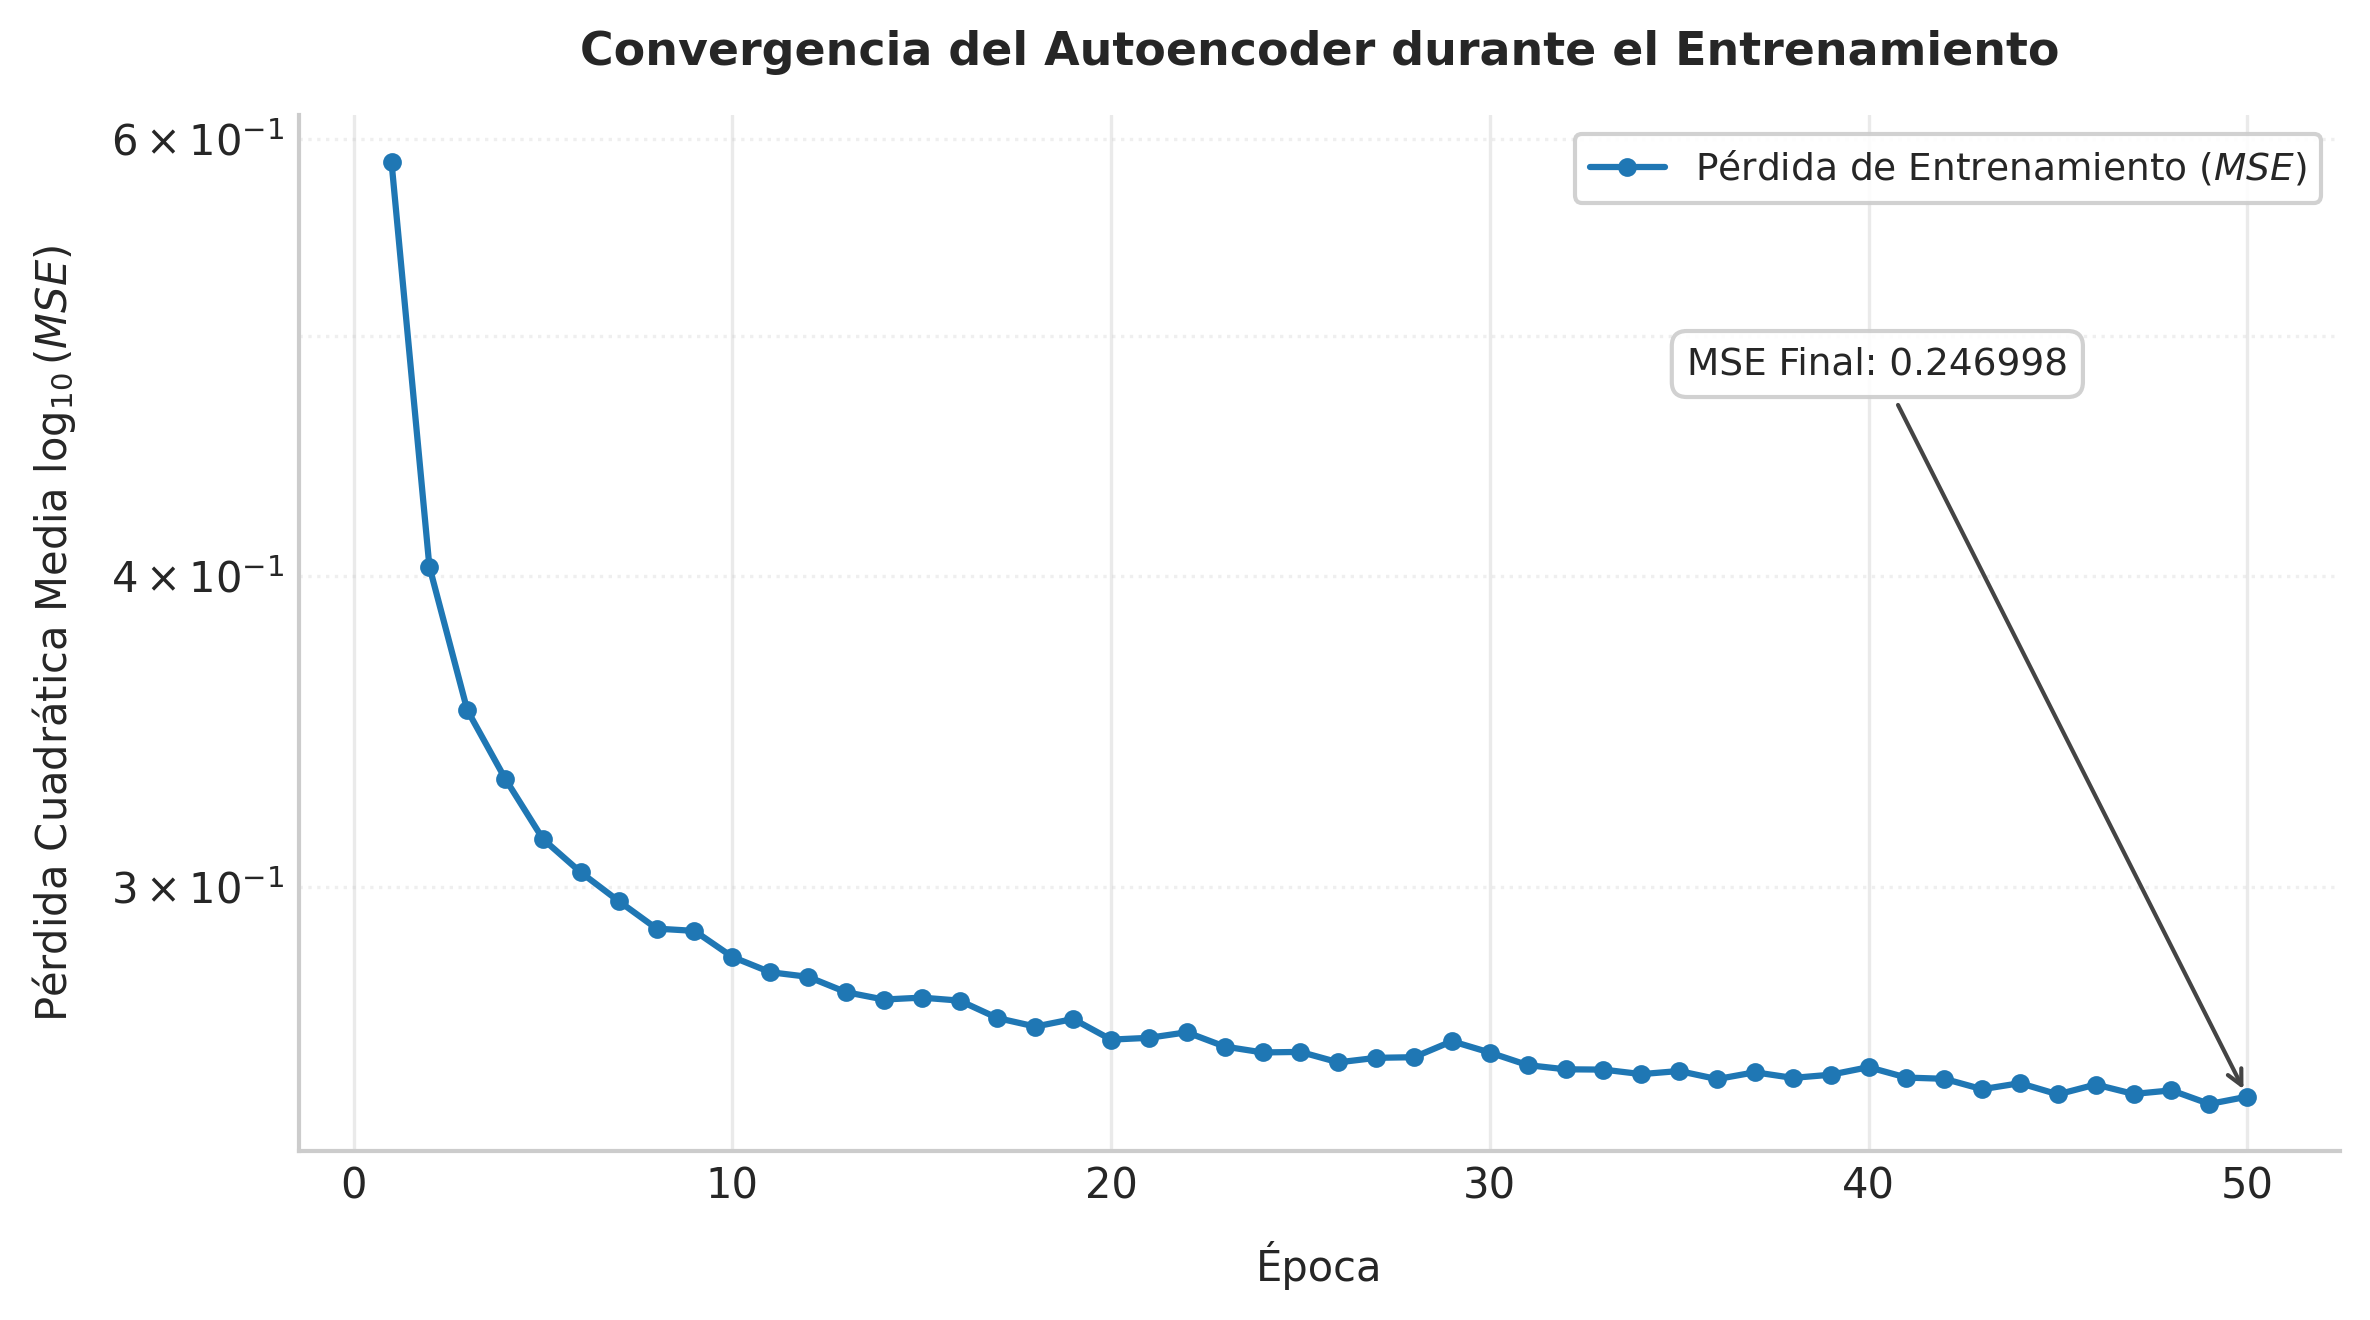

In [ ]:
import matplotlib.pyplot as plt

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

epocas = range(1, EPOCHS + 1)
color_loss = '#1f77b4'

# Graficar en escala semilogarítmica
ax.semilogy(epocas, train_losses, marker='o', markersize=3.5, linewidth=1.5, color=color_loss, label='Pérdida de Entrenamiento ($MSE$)')
# no se usó loglog por la poca cantidad de epocas
# Títulos y etiquetas claras
ax.set_title("Convergencia del Autoencoder durante el Entrenamiento", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Época", fontsize=10, labelpad=8)
ax.set_ylabel("Pérdida Cuadrática Media $\\log_{10}(MSE)$", fontsize=10, labelpad=8)

# Rejilla principal y secundaria tenue para facilitar la lectura logarítmica
ax.grid(True, which='major', linestyle='-', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)

# Limpieza de bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Anotación científica con el valor final
final_loss = train_losses[-1]
ax.annotate(
    f'MSE Final: {final_loss:.6f}',
    xy=(EPOCHS, final_loss),
    xytext=(0.68, 0.75),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->', lw=1, color='#444444'),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc', alpha=0.9)
)

ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

### Guardado del Modelo Entrenado

In [ ]:
# Definir directorio para guardar los modelos
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Ruta del archivo de guardado
model_path = MODELS_DIR / "autoencoder_creditcard.pth"

# Estructurar el checkpoint con pesos y configuración relevante
checkpoint = {
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_loss': train_losses[-1],
    'input_dim': INPUT_DIM,
    'bottleneck_dim': BOTTLENECK_DIM,
    'seed': SEED
}

# Guardar en disco
torch.save(checkpoint, model_path)
print(f"✅ Modelo y metadatos guardados exitosamente en: {model_path}")

✅ Modelo y metadatos guardados exitosamente en: ..\models\autoencoder_creditcard.pth


# Sección: 03_evaluation_and_threshold.ipynb

### Importación de Librerías y Configuración del Entorno
Se define el entorno de inferencia y se cargan librerías para métricas y visualización.
El dispositivo GPU/CPU se detecta automáticamente.


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
)
import joblib

# Permitir importar desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Configuración gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Dispositivo para inferencia: {device}")

PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

⚡ Dispositivo para inferencia: cpu


In [ ]:
# ---------------------------------------------------------
# 1. Cargar datos procesados y sus etiquetas reales
# ---------------------------------------------------------
X_test = np.load(PROCESSED_DATA_PATH / "X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH / "y_test.npy")

X_val = np.load(PROCESSED_DATA_PATH / "X_val.npy")
y_val = np.load(PROCESSED_DATA_PATH / "y_val.npy")

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Distribución de etiquetas y_test -> Lícitas (0): {(y_test == 0).sum()} | Ilícitas (1): {(y_test == 1).sum()}")

Dimensiones de X_test: (57109, 30)
Distribución de etiquetas y_test -> Lícitas (0): 56863 | Ilícitas (1): 246


In [ ]:
# ---------------------------------------------------------
# 2. Cargar la arquitectura e hiperparámetros del modelo
# ---------------------------------------------------------
INPUT_DIM = X_test.shape[1]

checkpoint = torch.load(MODELS_DIR / "autoencoder_creditcard.pth", map_location=device)
model = Autoencoder(
    input_dim=INPUT_DIM,
    bottleneck_dim=checkpoint.get("bottleneck_dim", 14),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

model.eval()
print("✅ Modelo de Credit Card cargado exitosamente en modo evaluación.")

✅ Modelo de Credit Card cargado exitosamente en modo evaluación.


In [ ]:
# ---------------------------------------------------------
# 3. Inferencia y Cálculo del Error de Reconstrucción (MSE)
# ---------------------------------------------------------
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

with torch.no_grad():
    X_test_reconstructed = model(X_test_tensor).cpu().numpy()
    X_val_reconstructed = model(X_val_tensor).cpu().numpy()

# Error Cuadrático Medio (MSE) por muestra en el espacio de características escalado
reconstruction_errors_test = np.mean(np.square(X_test - X_test_reconstructed), axis=1)
reconstruction_errors_val = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

print(f"\nError de Reconstrucción Promedio Test: {reconstruction_errors_test.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Test: {reconstruction_errors_test[y_test == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Test: {reconstruction_errors_test[y_test == 1].mean():.6f}")
print(f"Error de Reconstrucción Promedio Val:  {reconstruction_errors_val.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Val:  {reconstruction_errors_val[y_val == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Val:  {reconstruction_errors_val[y_val == 1].mean():.6f}")


Error de Reconstrucción Promedio Test: 0.172564
  └─ Promedio en Lícitas (Clase 0) Test: 0.109243
  └─ Promedio en Ilícitas (Clase 1) Test: 14.809408
Error de Reconstrucción Promedio Val:  0.174703
  └─ Promedio en Lícitas (Clase 0) Val:  0.107316
  └─ Promedio en Ilícitas (Clase 1) Val:  15.751208


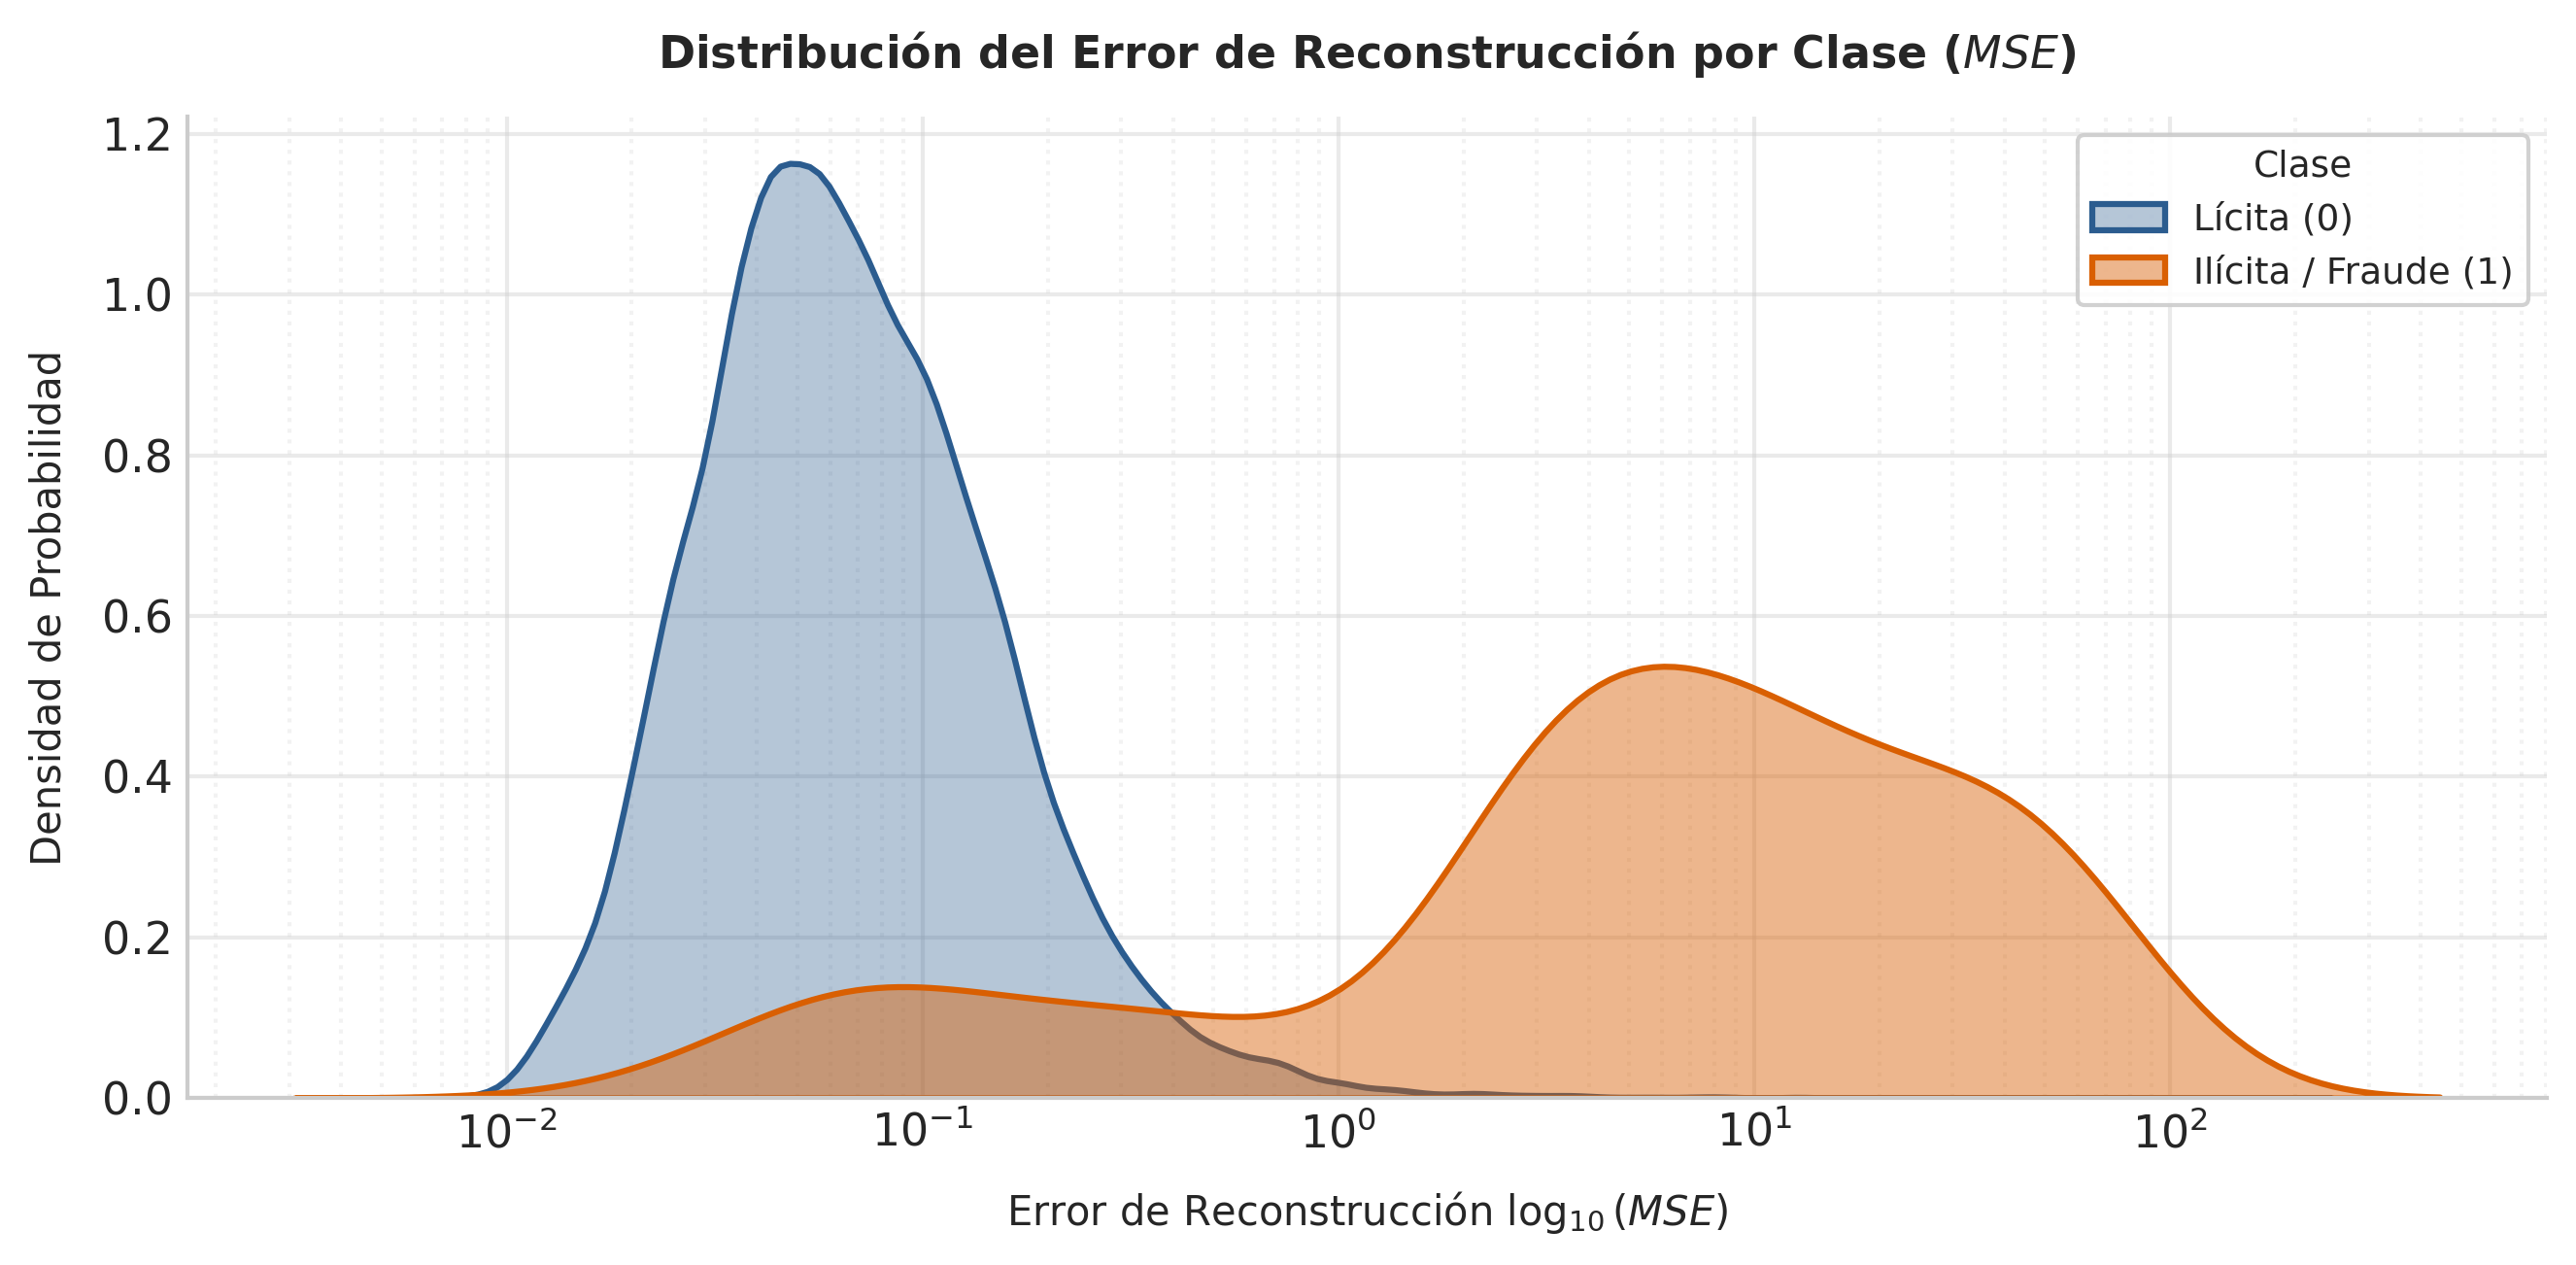

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=300)

# Paleta semántica coherente con todo el proyecto
color_licita = '#2b5c8f'   # Azul sobrio
color_ilicita = '#d95f02'  # Naranja/Rojo de alerta

# Estimación de Densidad Kernel (KDE) con transformación logarítmica en el eje X
sns.kdeplot(
    data=reconstruction_errors_test[y_test == 0],
    label="Lícita (0)",
    color=color_licita,
    fill=True,
    alpha=0.35,
    linewidth=1.5,
    log_scale=True,
    ax=ax
)

sns.kdeplot(
    data=reconstruction_errors_test[y_test == 1],
    label="Ilícita / Fraude (1)",
    color=color_ilicita,
    fill=True,
    alpha=0.45,
    linewidth=1.5,
    log_scale=True,
    ax=ax
)

# Etiquetas y títulos para publicación
ax.set_title("Distribución del Error de Reconstrucción por Clase ($MSE$)", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Error de Reconstrucción $\\log_{10}(MSE)$", fontsize=10, labelpad=8)
ax.set_ylabel("Densidad de Probabilidad", fontsize=10, labelpad=8)

# Rejillas tenue para facilitar lectura de magnitudes
ax.grid(True, which='major', linestyle='-', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.25)
ax.set_axisbelow(True)

# Limpieza de bordes (Chart Junk)
sns.despine(top=True, right=True)

# Leyenda formal
ax.legend(title="Clase", title_fontsize='9', frameon=True, facecolor='white', framealpha=0.9, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


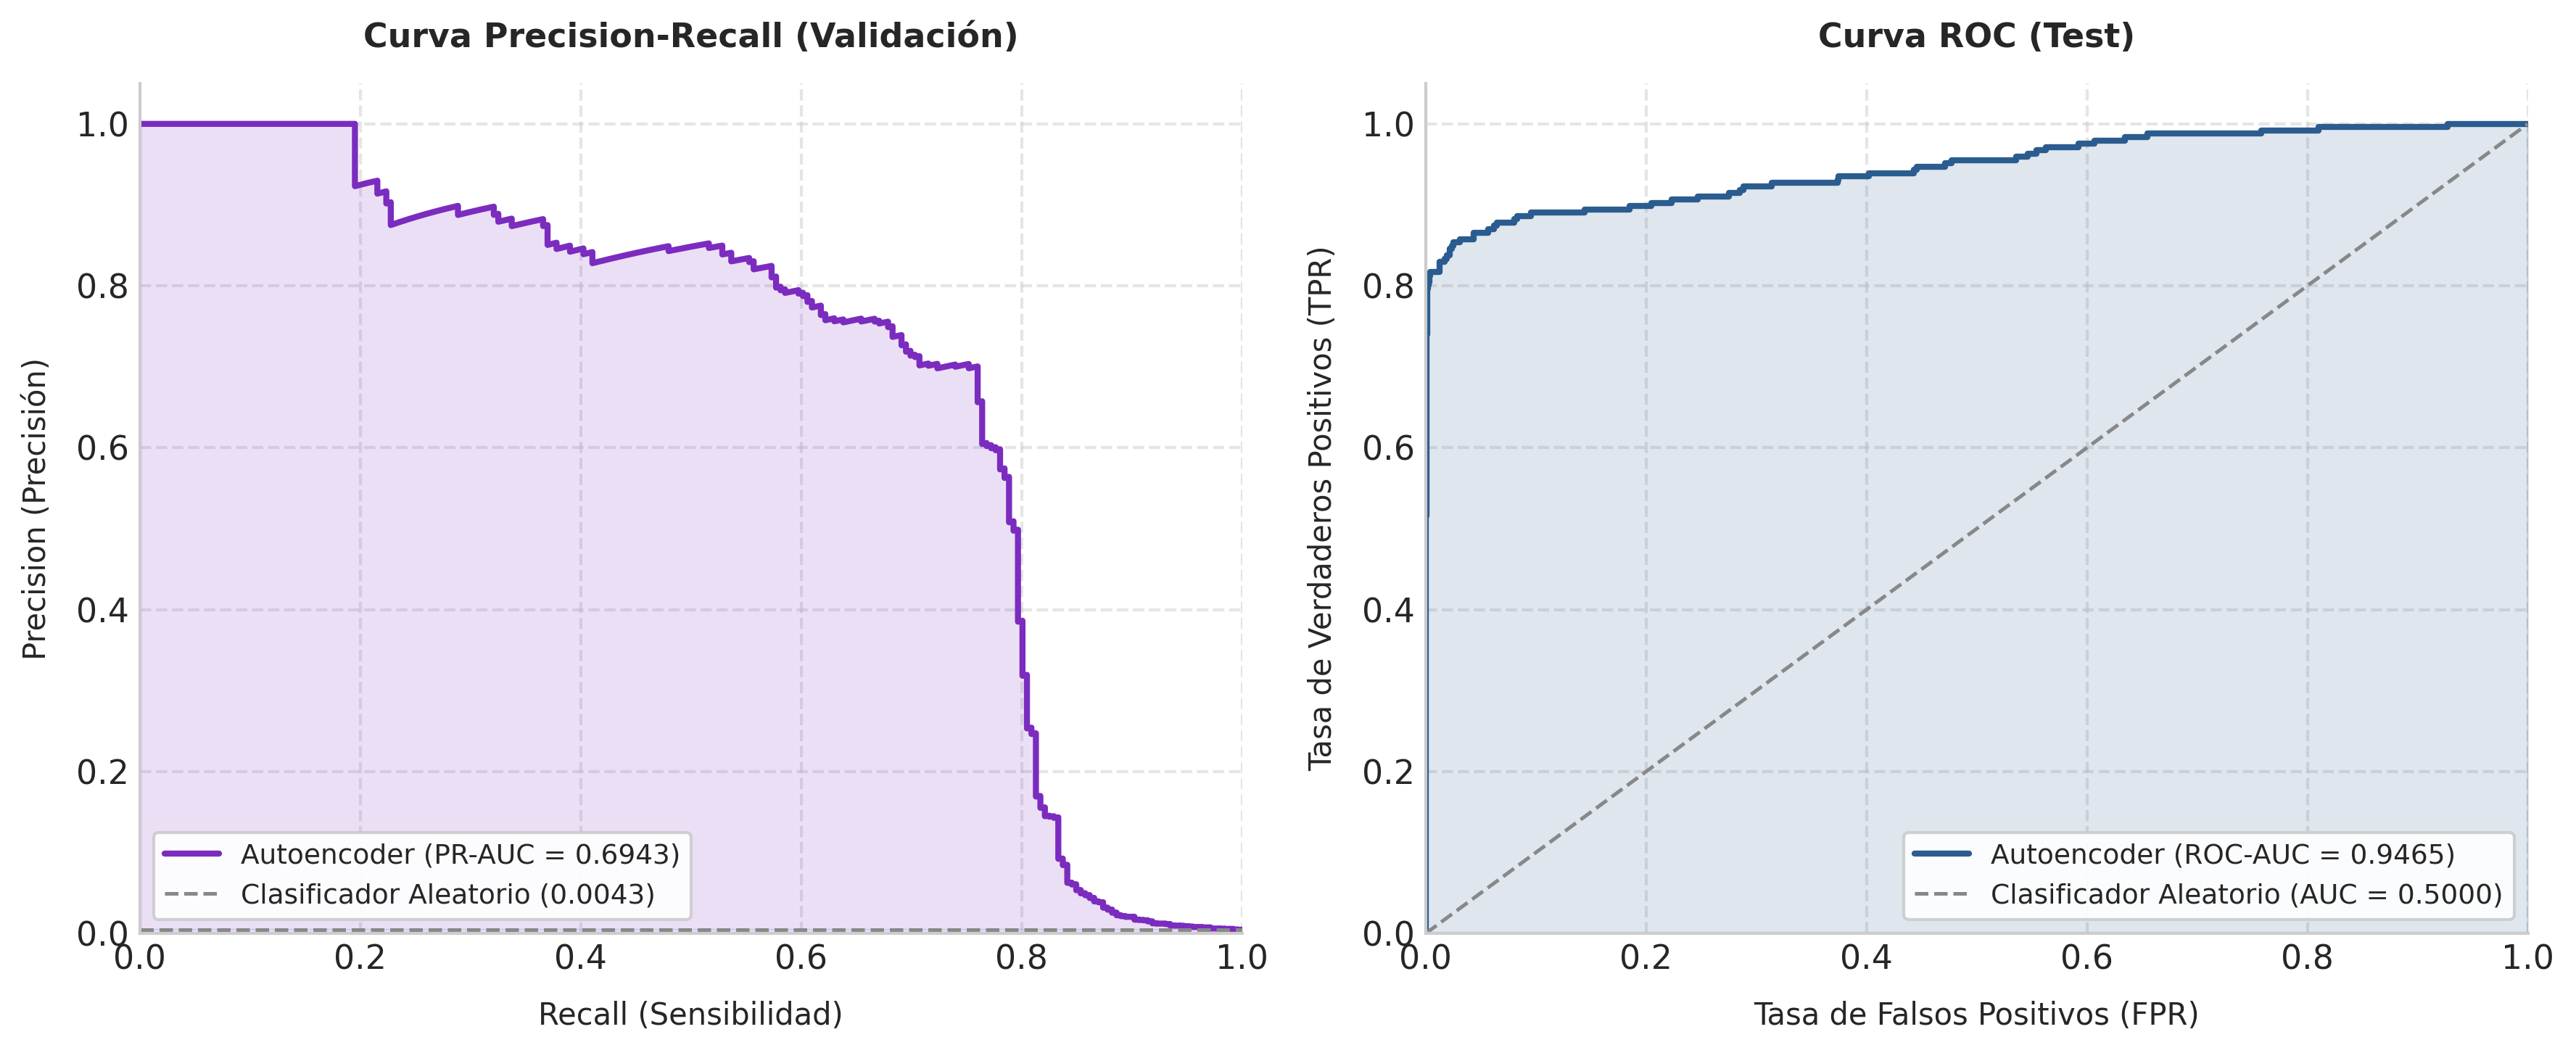

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, roc_auc_score

# Cálculo de métricas
precision_v, recall_v, _ = precision_recall_curve(y_val, reconstruction_errors_val)
pr_auc_val = auc(recall_v, precision_v)

fpr, tpr, _ = roc_curve(y_test, reconstruction_errors_test)
roc_auc_test = roc_auc_score(y_test, reconstruction_errors_test)

# Cálculo de la línea base para PR (Prevalencia de la clase positiva en Validación)
no_skill_pr = (y_val == 1).sum() / len(y_val)

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

color_pr = '#7b2cbf'   # Púrpura sobrio
color_roc = '#2b5c8f'  # Azul sobrio

# --- 1. Curva Precision-Recall (Validación) ---
ax1 = axes[0]
ax1.plot(recall_v, precision_v, color=color_pr, lw=2, label=f'Autoencoder (PR-AUC = {pr_auc_val:.4f})')
ax1.axhline(y=no_skill_pr, color='#888888', linestyle='--', lw=1.2, label=f'Clasificador Aleatorio ({no_skill_pr:.4f})')
ax1.fill_between(recall_v, precision_v, no_skill_pr, color=color_pr, alpha=0.15)

ax1.set_title("Curva Precision-Recall (Validación)", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Recall (Sensibilidad)", fontsize=10, labelpad=8)
ax1.set_ylabel("Precision (Precisión)", fontsize=10, labelpad=8)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.legend(loc="lower left", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

# --- 2. Curva ROC (Test) ---
ax2 = axes[1]
ax2.plot(fpr, tpr, color=color_roc, lw=2, label=f'Autoencoder (ROC-AUC = {roc_auc_test:.4f})')
ax2.plot([0, 1], [0, 1], color='#888888', linestyle='--', lw=1.2, label='Clasificador Aleatorio (AUC = 0.5000)')
ax2.fill_between(fpr, tpr, color=color_roc, alpha=0.15)

ax2.set_title("Curva ROC (Test)", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10, labelpad=8)
ax2.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10, labelpad=8)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

# Eliminar bordes innecesarios (Chart Junk)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5. Calcular umbrales, F1 y métricas de validación/test
# ---------------------------------------------------------
thresholds_v = np.linspace(reconstruction_errors_val.min(), reconstruction_errors_val.max(), 1000)
precision_valid = np.zeros_like(thresholds_v)
recall_valid = np.zeros_like(thresholds_v)
f1_scores = np.zeros_like(thresholds_v)

for i, threshold in enumerate(thresholds_v):
    y_pred_val = (reconstruction_errors_val >= threshold).astype(int)
    tp = np.sum((y_pred_val == 1) & (y_val == 1))
    fp = np.sum((y_pred_val == 1) & (y_val == 0))
    fn = np.sum((y_pred_val == 0) & (y_val == 1))

    precision_valid[i] = tp / (tp + fp) if tp + fp else 0.0
    recall_valid[i] = tp / (tp + fn) if tp + fn else 0.0
    f1_scores[i] = 2 * precision_valid[i] * recall_valid[i] / (precision_valid[i] + recall_valid[i]) if (precision_valid[i] + recall_valid[i]) else 0.0

best_idx = int(np.nanargmax(f1_scores))
optimal_threshold = float(thresholds_v[best_idx])
best_f1 = float(f1_scores[best_idx])

# Predicciones en test y métricas finales

y_pred = (reconstruction_errors_test >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
avg_prec_test = average_precision_score(y_test, reconstruction_errors_test)


### Selección del Umbral Óptimo (τ) en Validación
Se obtiene el umbral que maximiza el F1 score sobre validación.
Este umbral se usa luego para clasificar el conjunto de test.

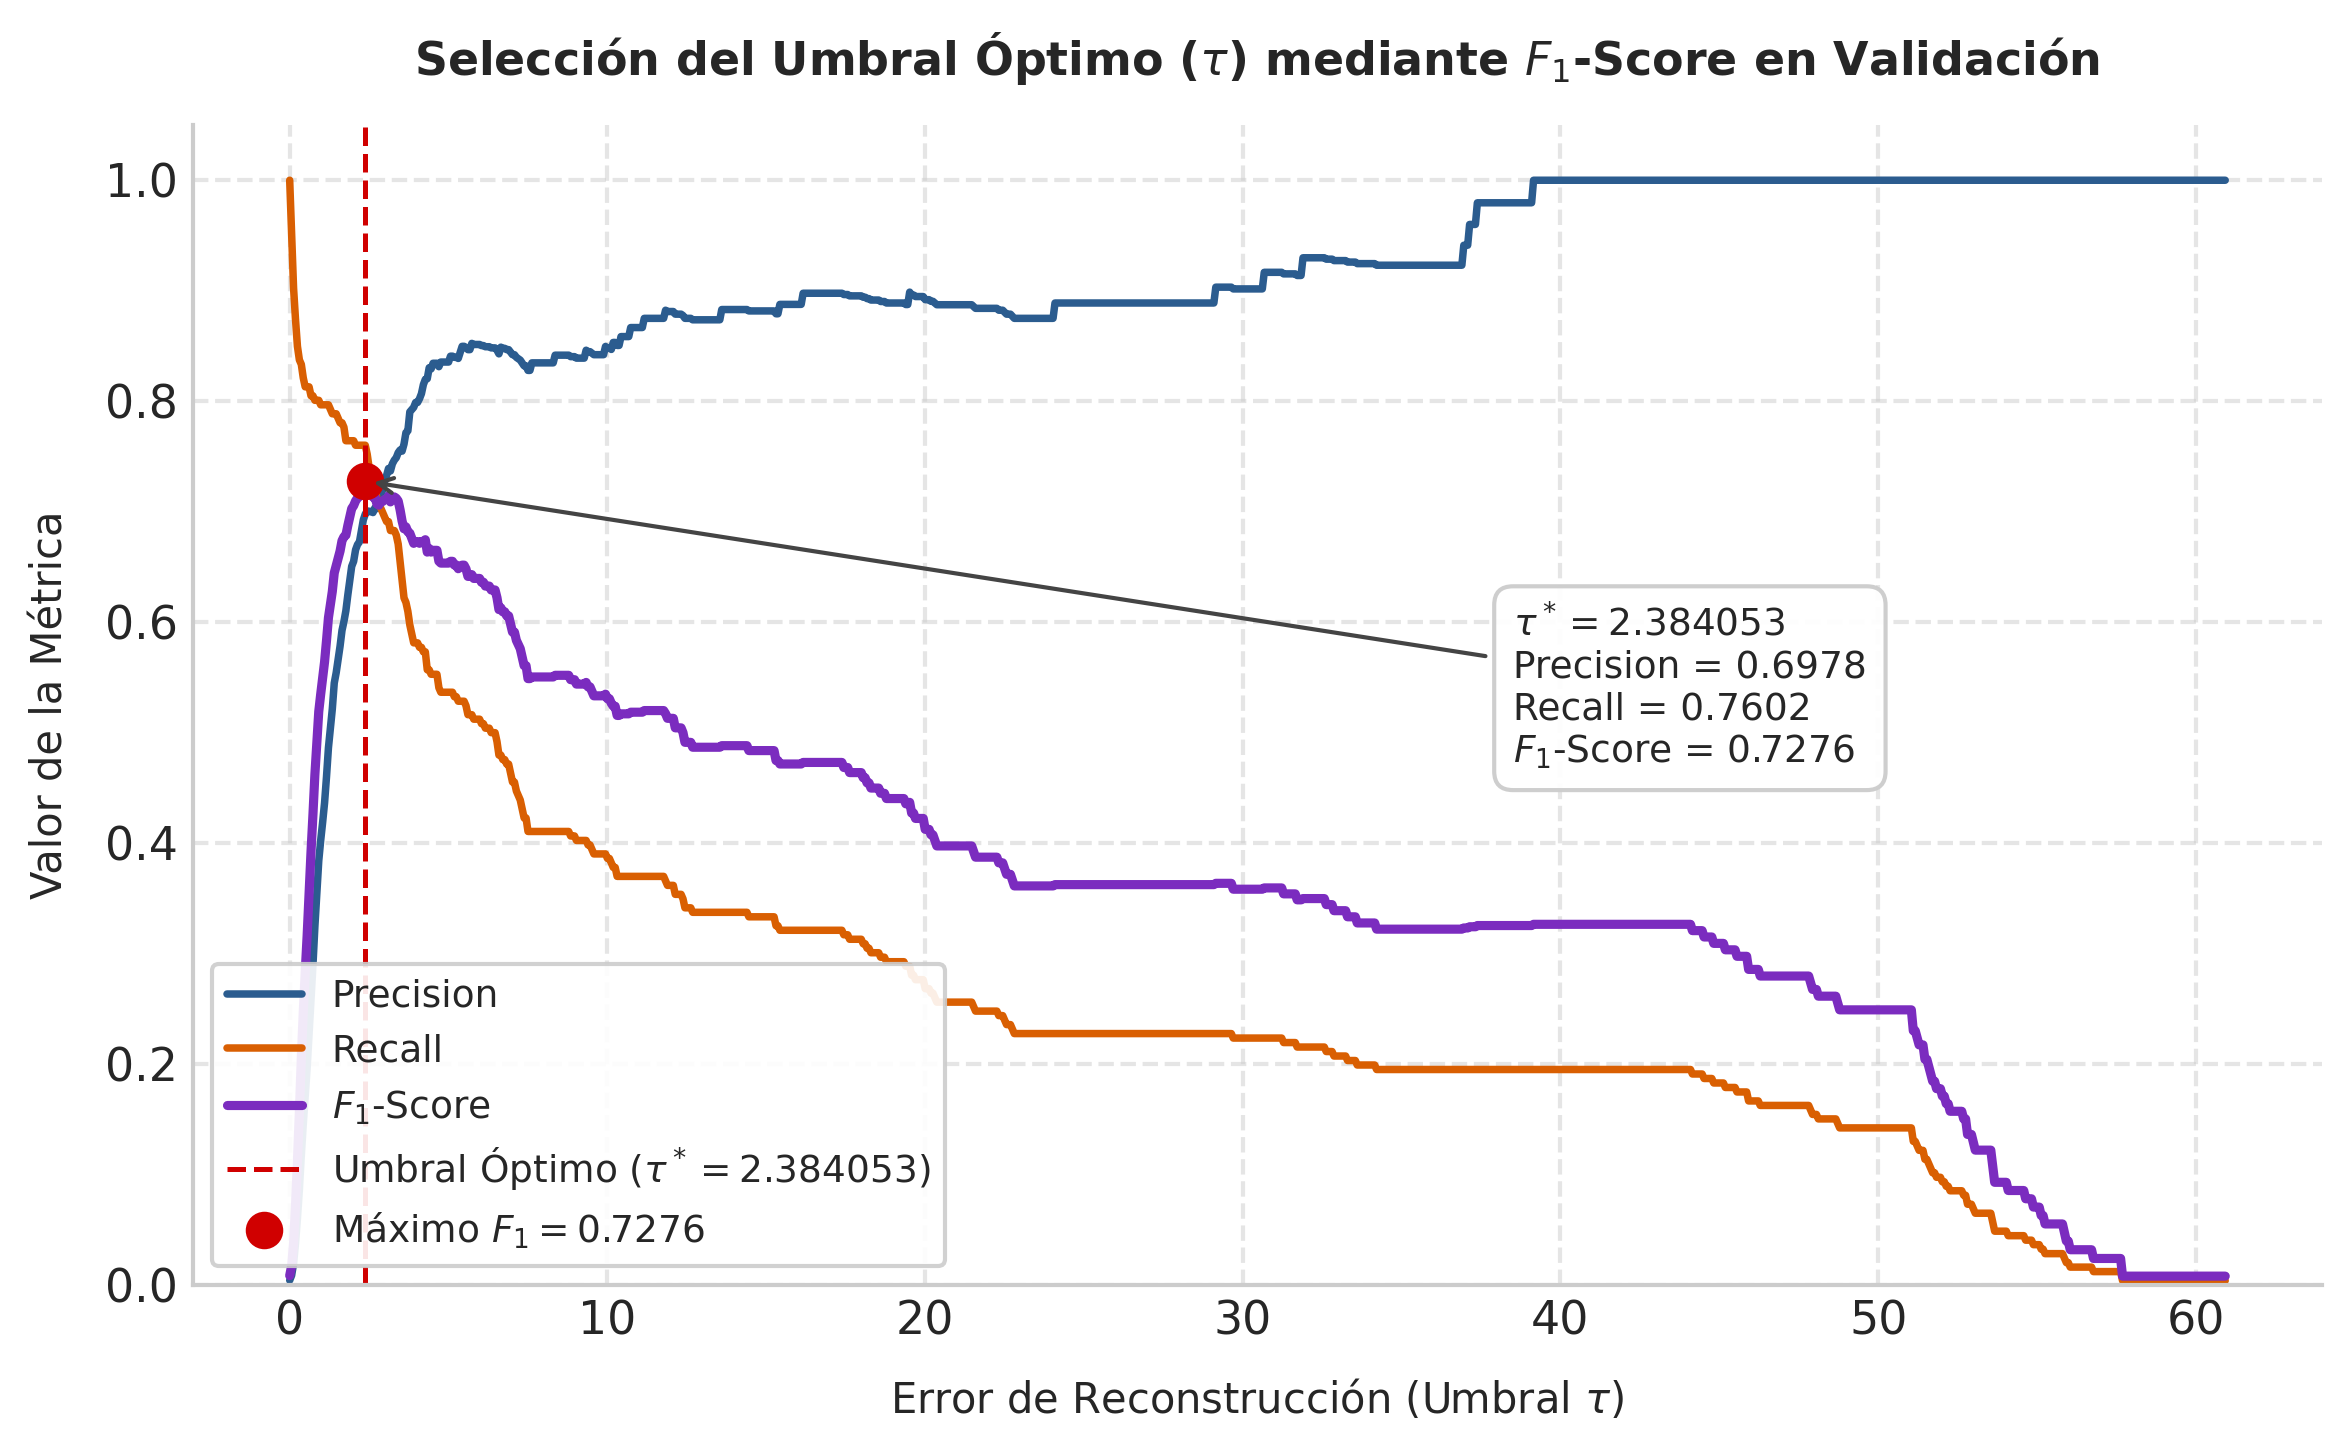

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Graficar la evolución de Precision, Recall y F1 en función del Umbral
ax.plot(thresholds_v, precision_valid, color='#2b5c8f', lw=1.8, label='Precision')
ax.plot(thresholds_v, recall_valid, color='#d95f02', lw=1.8, label='Recall')
ax.plot(thresholds_v, f1_scores, color='#7b2cbf', lw=2.2, label='$F_1$-Score')

# Marcar la línea vertical y el punto en el umbral óptimo
ax.axvline(x=optimal_threshold, color='#d00000', linestyle='--', lw=1.2,
           label=f'Umbral Óptimo ($\\tau^* = {optimal_threshold:.6f}$)')
ax.plot(optimal_threshold, best_f1, marker='o', markersize=8, color='#d00000',
        linestyle='None', label=f'Máximo $F_1 = {best_f1:.4f}$')

# Formato formal de ejes y títulos
ax.set_title("Selección del Umbral Óptimo ($\\tau$) mediante $F_1$-Score en Validación", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Error de Reconstrucción (Umbral $\\tau$)", fontsize=10, labelpad=8)
ax.set_ylabel("Valor de la Métrica", fontsize=10, labelpad=8)
ax.set_ylim([0.0, 1.05])

# Anotación científica flotante con los valores exactos
anotacion = (f"$\\tau^* = {optimal_threshold:.6f}$\n"
             f"Precision = {precision_valid[best_idx]:.4f}\n"
             f"Recall = {recall_valid[best_idx]:.4f}\n"
             f"$F_1$-Score = {best_f1:.4f}")

ax.annotate(anotacion,
            xy=(optimal_threshold, best_f1),
            xytext=(0.62, 0.45),
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1, color='#444444'),
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.95))

# Cuadrícula y limpieza de bordes
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

### Evaluación Final en Test y Métricas
Se evalúan precisión, recall, F1 y curvas ROC/PR en el conjunto de prueba.
También se generan matrices de confusión para validar el desempeño por clase.

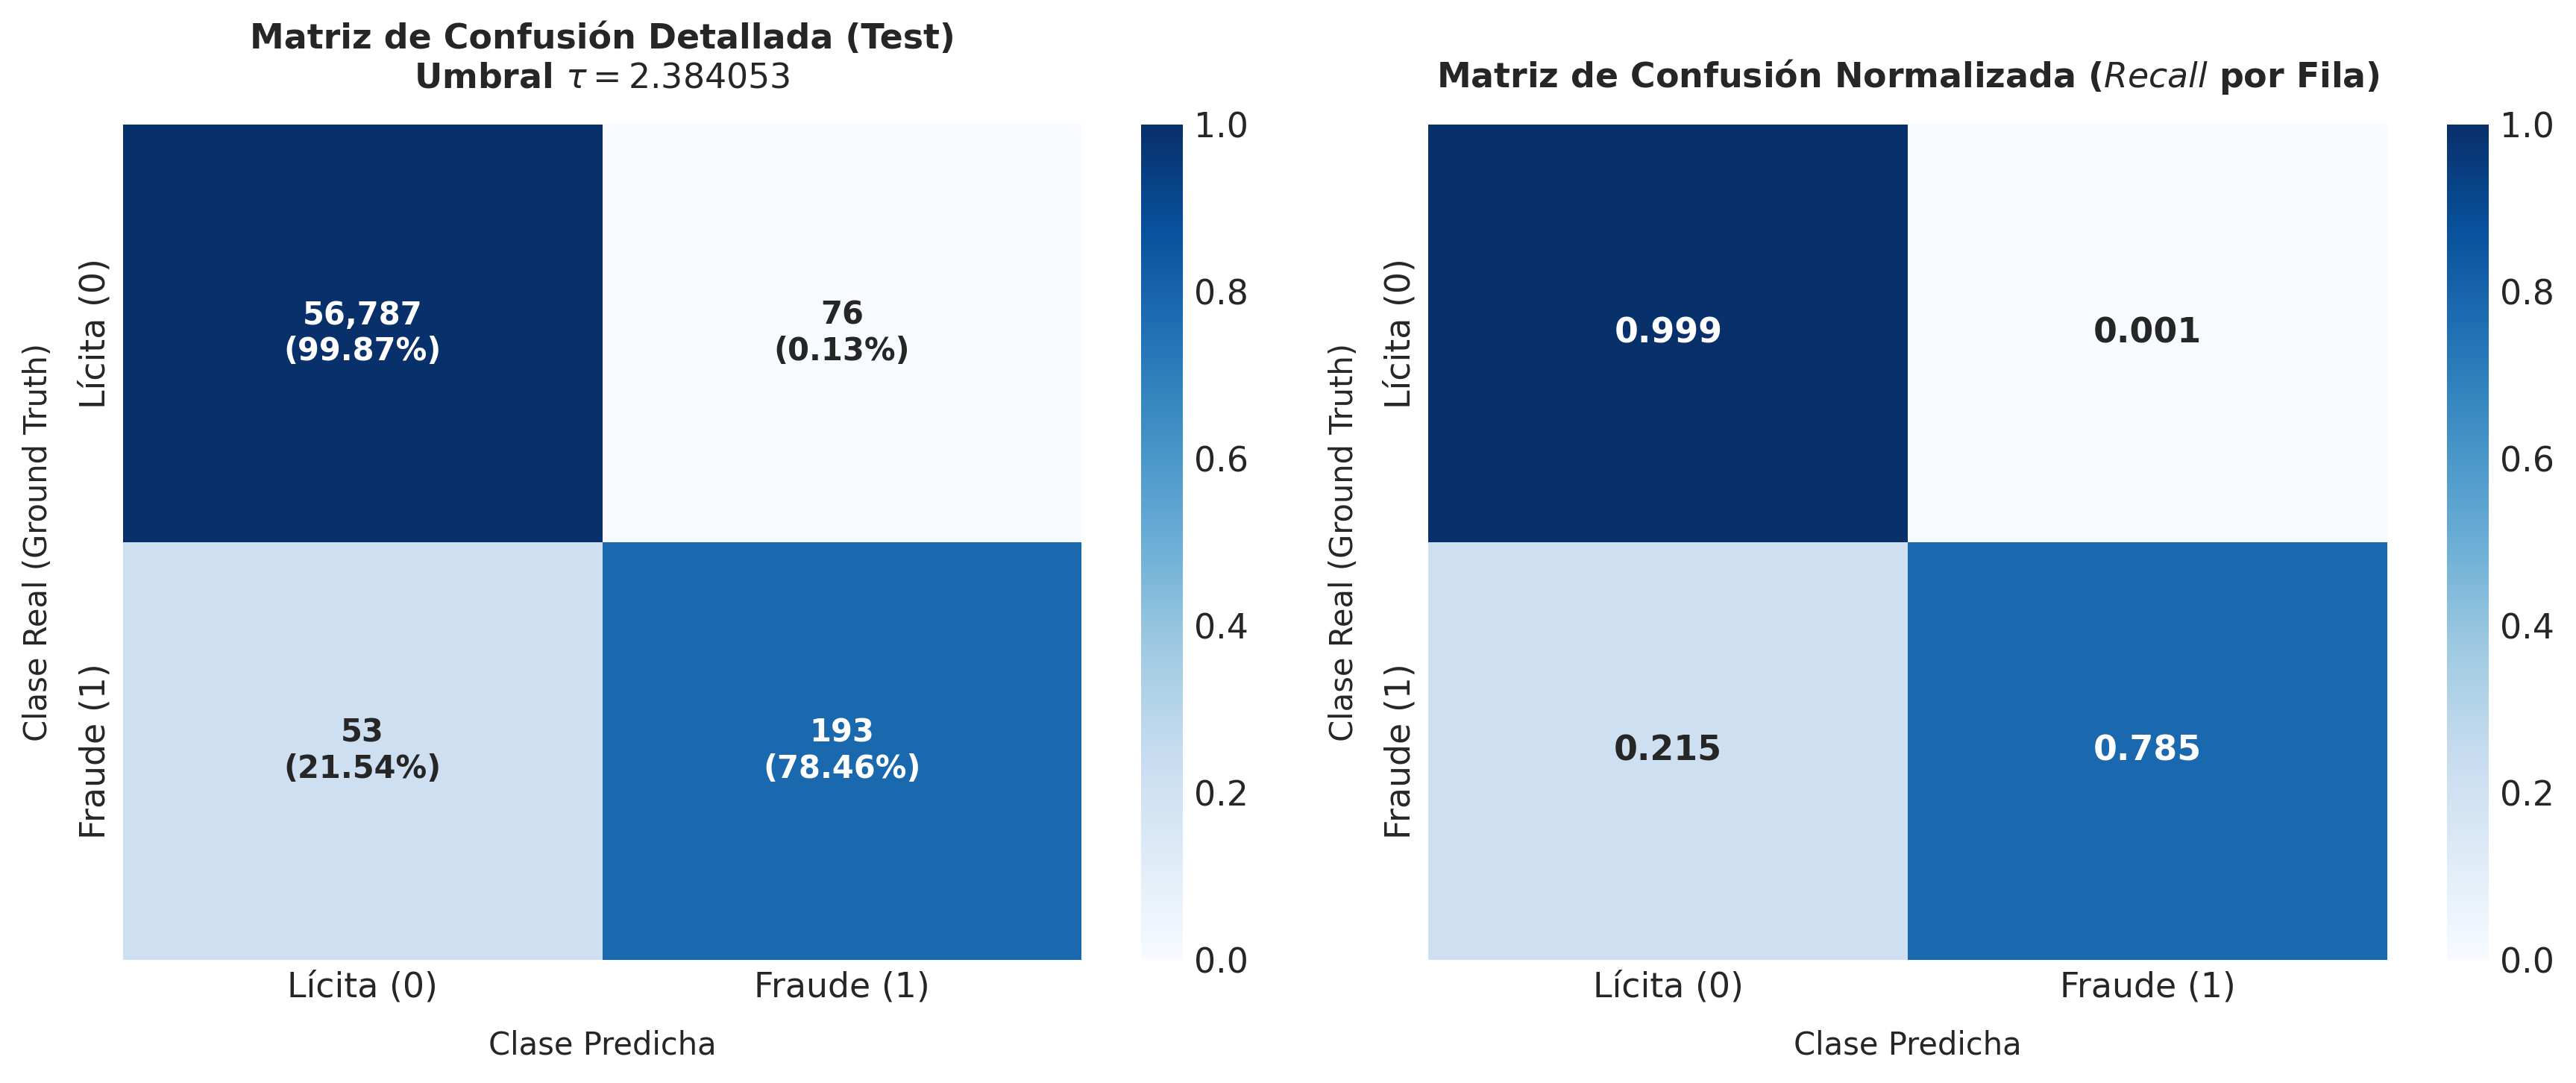

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estilo global académico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

labels = ["Lícita (0)", "Fraude (1)"]

# --- Subplot 1: Matriz con Conteos + Porcentajes Combinados ---
ax1 = axes[0]

# Construir anotaciones combinadas: Conteo absoluto y Porcentaje por fila
annot_matrix = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_norm[i, j] * 100
        annot_matrix[i, j] = f"{count:,}\n({pct:.2f}%)"

sns.heatmap(
    cm_norm,
    annot=annot_matrix,
    fmt="",
    cmap="Blues",
    cbar=True,
    ax=ax1,
    vmin=0, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10, "weight": "bold"}
)

ax1.set_title(f"Matriz de Confusión Detallada (Test)\nUmbral $\\tau = {optimal_threshold:.6f}$", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("Clase Predicha", fontsize=10, labelpad=8)
ax1.set_ylabel("Clase Real (Ground Truth)", fontsize=10, labelpad=8)

# --- Subplot 2: Rendimiento Relativo Normalizado por Fila ---
ax2 = axes[1]

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=True,
    ax=ax2,
    vmin=0, vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 11, "weight": "bold"}
)

ax2.set_title("Matriz de Confusión Normalizada ($Recall$ por Fila)", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Clase Predicha", fontsize=10, labelpad=8)
ax2.set_ylabel("Clase Real (Ground Truth)", fontsize=10, labelpad=8)

# Ajustes generales de estética
for ax in axes:
    ax.tick_params(axis='both', which='both', length=0)  # Quitar marcas de ticks

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------
# 8. Guardar Artefactos Finales y Configuración
# ---------------------------------------------------------
SEED = 42
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_val": float(best_f1),
    "pr_auc_val": float(pr_auc_val),
    "avg_precision_test": float(avg_prec_test),
    "roc_auc_test": float(roc_auc_test),
    "seed": int(SEED)
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")
np.save(PROCESSED_DATA_PATH / "reconstruction_errors_test.npy", reconstruction_errors_test)
np.save(PROCESSED_DATA_PATH / "y_pred_test.npy", y_pred)

print(f"\n💾 Artefactos guardados exitosamente en: {PROCESSED_DATA_PATH}")
print("   ├─ threshold_config.joblib")
print("   ├─ reconstruction_errors_test.npy")
print("   └─ y_pred_test.npy")


💾 Artefactos guardados exitosamente en: ..\data\processed
   ├─ threshold_config.joblib
   ├─ reconstruction_errors_test.npy
   └─ y_pred_test.npy


# Archivo model.py

In [ ]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    """
    Autoencoder en PyTorch configurado para detección de anomalías/fraude
    en el dataset Credit Card.
    """
    def __init__(self, input_dim: int = 29, bottleneck_dim: int = 14, dropout_rate: float = 0.1):
        super(Autoencoder, self).__init__()

        # Encoder: compresión progresiva de características
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),

            nn.Linear(32, bottleneck_dim),
            nn.LeakyReLU(0.2)
        )

        # Decoder: reconstrucción del vector original
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout_rate),

            nn.Linear(64, input_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Obtiene la representación latente (bottleneck)."""
        return self.encoder(x)

    def decode(self, latent: torch.Tensor) -> torch.Tensor:
        """Reconstruye la entrada a partir del vector latente."""
        return self.decoder(latent)